# Regression Problem - Predicting GDP Based on COVID-19 Data

## Goal
Predict the GDP of a country based on COVID-19 statistics and economic indicators using supervised learning regression models.

## Data Preparation

### Imports

In [111]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.preprocessing import StandardScaler

### Loading the Dataset

In [112]:
df = pd.read_csv("Excel Files/Covid19_With_GDP_Values.csv")
df.head()

,Unnamed: 0,Country/Region,Date,Province/State,Confirmed,Deaths,Recovered,GDP,Unemployment,CPI
0,0,Afghanistan,2021-01-01,0,52513.0,2201.0,41727.0,1.426650e+10,11.934,NaN
1,1,Afghanistan,2022-01-01,0,158107.0,7356.0,0.0,1.450216e+10,14.100,NaN
2,2,Albania,2021-01-01,0,58316.0,1181.0,33634.0,1.793057e+10,12.473,123.448662
3,3,Albania,2022-01-01,0,210224.0,3217.0,0.0,1.891638e+10,11.588,131.750835
4,4,Algeria,2021-01-01,0,99897.0,2762.0,67395.0,1.862654e+11,13.607,166.218895


### Step 1 - Removing Unknown and Meaningless Columns

**`Unnamed: 0`** - This column is an artifact from the CSV export process. It is a duplicate of the DataFrame's default integer index and carries no meaningful information. Removing it avoids redundancy.

In [113]:
df = df.drop("Unnamed: 0", axis=1)

### Step 2 & 3 - Handling Missing Values and Removing Duplicates

**Missing values:** We chose to drop rows containing missing values (`dropna`) rather than imputing them. Since the dataset is relatively small and each row represents a country-year observation, imputing values (e.g., with the mean) could introduce misleading data — for example, filling in a missing CPI value with the global average would not accurately reflect that specific country's economic situation. Dropping these rows ensures that only complete and reliable observations are used for training.

**Duplicates:** Duplicate rows are removed to prevent the model from being biased toward countries that appear more than once with identical data.

In [114]:
df = df.dropna().drop_duplicates()

### Step 4 - Aggregating Data by Country

The dataset contains two rows per country (one for 2021 and one for 2022). To avoid data leakage and ensure each observation is independent, we aggregate the data so that each country is represented by a single row.

Before aggregating, we remove columns that cannot be meaningfully averaged:
- **`Date`** - A categorical time label (e.g., "2021-01-01"); averaging dates has no meaningful interpretation.
- **`Province/State`** - A categorical identifier with a constant value of 0 for most entries; it adds no predictive value.

We then group by `Country/Region` and compute the **mean** of all remaining numeric columns, producing one aggregated row per country.

In [115]:
df = df.drop(
    ["Date", "Province/State"],
    axis=1,
)
df = df.groupby("Country/Region").mean()
df

,Confirmed,Deaths,Recovered,GDP,Unemployment,CPI
Country/Region,,,,,,
Albania,134270.0,2199.0,16817.0,1.842347e+10,12.0305,127.599748
Algeria,159357.5,4523.0,33697.5,2.059128e+11,13.0220,173.919413
Andorra,15928.5,112.0,3731.5,3.352643e+09,12.4370,181.619932
Angola,49983.0,1088.5,5573.0,8.545244e+10,15.2460,645.998608
Antigua and Barbuda,2221.0,62.0,74.0,1.734550e+09,14.6930,123.019852
...,...,...,...,...,...,...
Uzbekistan,138106.0,1049.5,37622.0,7.537072e+10,4.9400,375.337755
Vanuatu,4.0,0.5,0.5,9.863067e+08,4.9525,130.479616
West Bank and Gaza,304485.5,3168.5,59463.0,1.863725e+10,25.4050,115.185995


### Step 5 - Log-Transforming Skewed Variables

`GDP`, `Confirmed`, `Deaths`, and `Recovered` all span many orders of magnitude across countries (`GDP` alone ranges from ~$1B to ~$23T). On the raw scale, no linear model can fit such a wide range cleanly — the fit is dominated by a few large countries.

We apply `np.log1p` (= log(1 + x)) to compress the range and make the relationship more linear. `log1p` is used instead of `log` so that zero values are handled safely. Note that this puts the target on a **log-dollar** scale, so all reported MAE/MSE/RMSE values below are in log-GDP units rather than dollars.

In [116]:
df["GDP"] = np.log1p(df["GDP"])
df["Confirmed"] = np.log1p(df["Confirmed"])
df["Deaths"] = np.log1p(df["Deaths"])
df["Recovered"] = np.log1p(df["Recovered"])

### Step 6 - Converting Categorical Features & Separating Features and Label

After aggregation, `Country/Region` serves as the index of the DataFrame rather than a feature column. All remaining columns (Confirmed, Deaths, Recovered, Unemployment, CPI) are already numerical, so there is **no need to apply `get_dummies()`** — there are no categorical features left to encode.

We now separate the data into:
- **X (features):** Confirmed, Deaths, Recovered, Unemployment, CPI
- **y (label):** GDP

In [117]:
X = df.drop("GDP", axis=1)
y = df["GDP"]

## Data Exploration

In this section we examine the relationships between all features and the label (GDP) using:
1. A **pairplot** to visually inspect feature-to-feature and feature-to-label relationships.
2. **Scatter plots** of each feature against GDP for a closer look.
3. A **correlation heatmap** to quantify these relationships numerically.

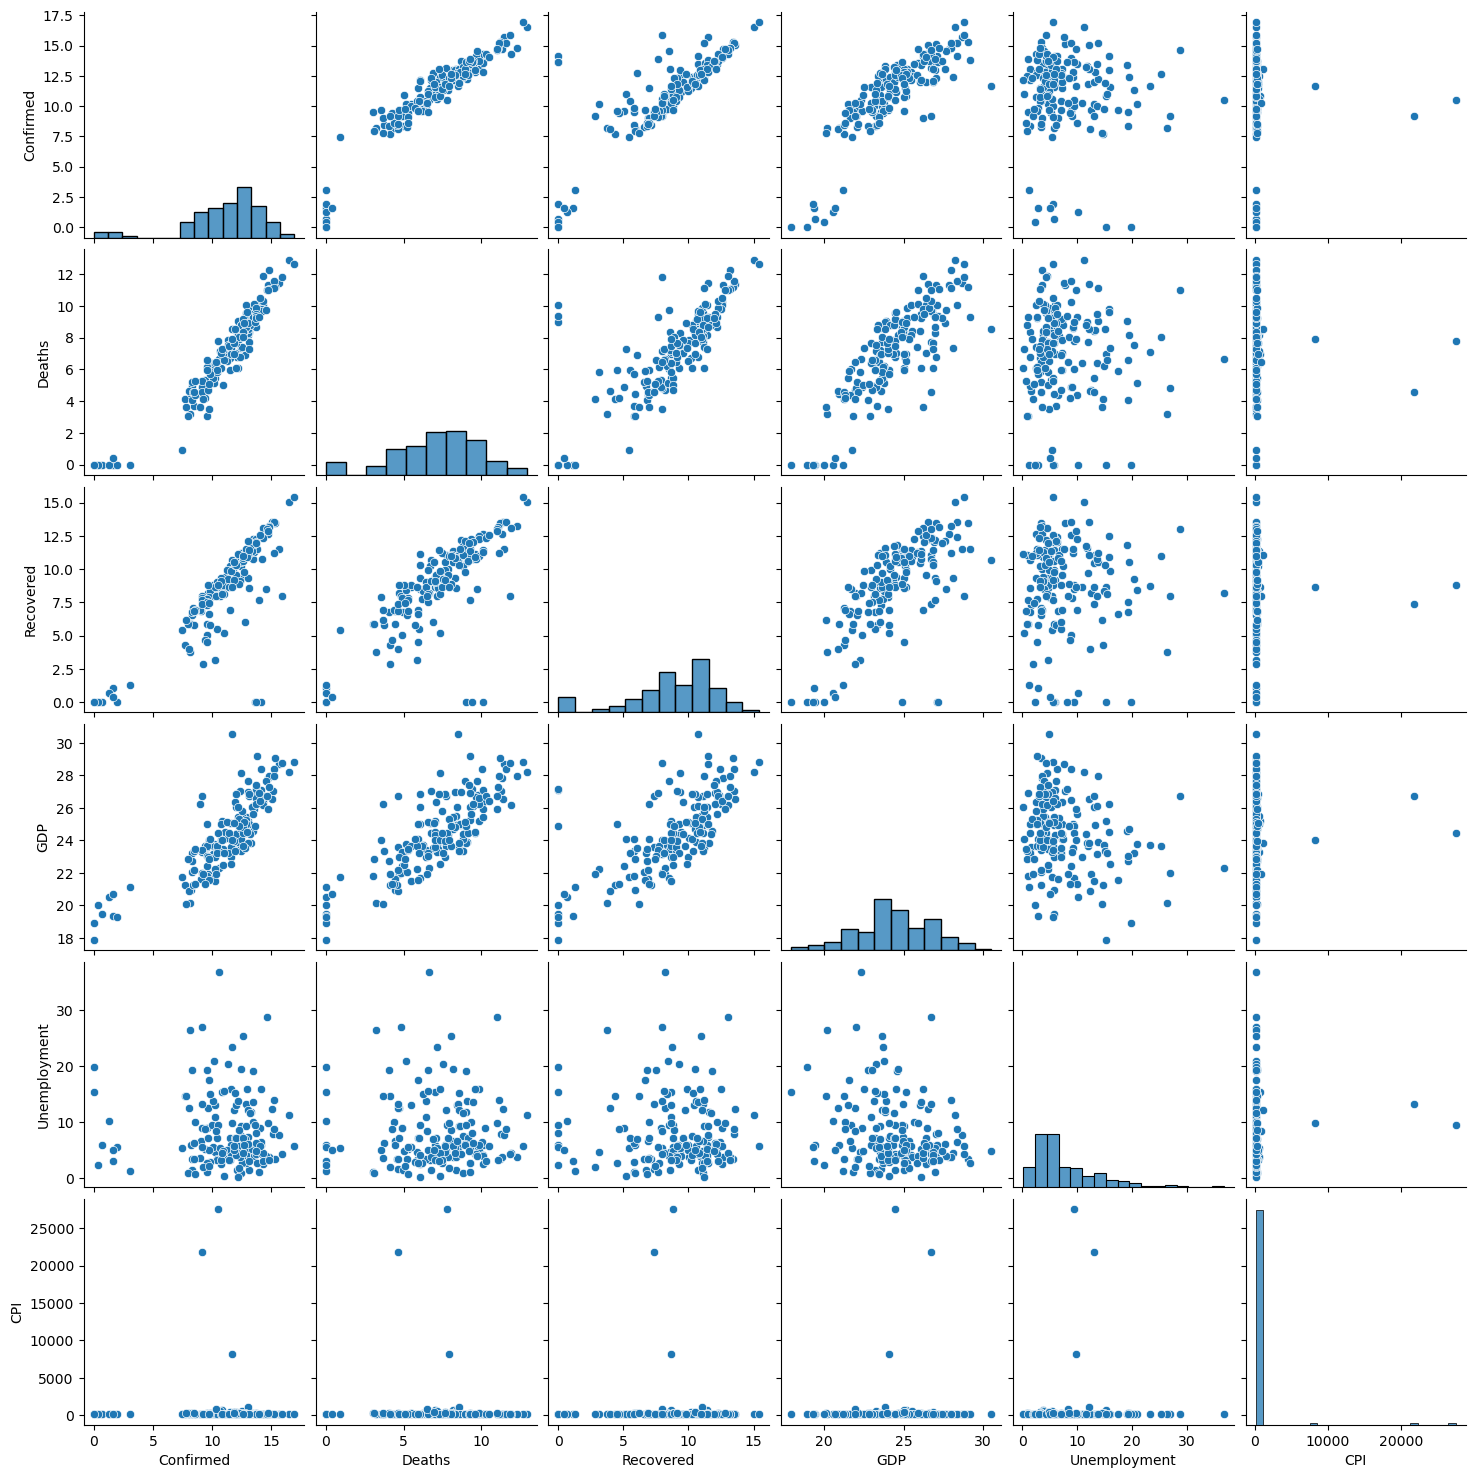

In [118]:
sns.pairplot(data=df)

### Pairplot Observations

**Feature-to-feature relationships:**
- **Confirmed, Deaths, and Recovered** show strong positive linear relationships with each other. This is expected — countries with more confirmed COVID-19 cases will naturally report more deaths and more recoveries. This indicates **multicollinearity** between these three features, which may affect linear regression model stability.

**Feature-to-label (GDP) relationships:**
- **Confirmed, Deaths, and Recovered** each show a moderate positive trend with GDP. Wealthier countries (higher GDP) tend to report higher COVID numbers, likely due to larger populations and more developed testing and reporting infrastructure.
- **Unemployment** shows no clear linear pattern with GDP — the scatter is widely dispersed.
- **CPI** shows no clear linear pattern with GDP either, and contains extreme outliers (values above 20,000, likely due to hyperinflation in countries like Zimbabwe).

**Distribution shapes (diagonal histograms):**
- All features and the label are **heavily right-skewed**, with most countries clustering near low values and a few outliers dominating the upper range (e.g., the US, India, and Brazil for COVID statistics; the US, China, and Japan for GDP).

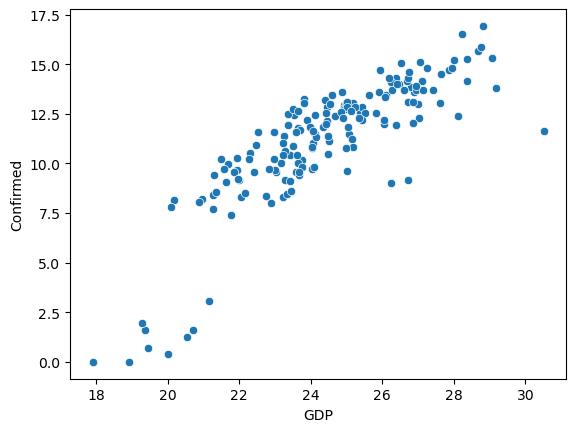

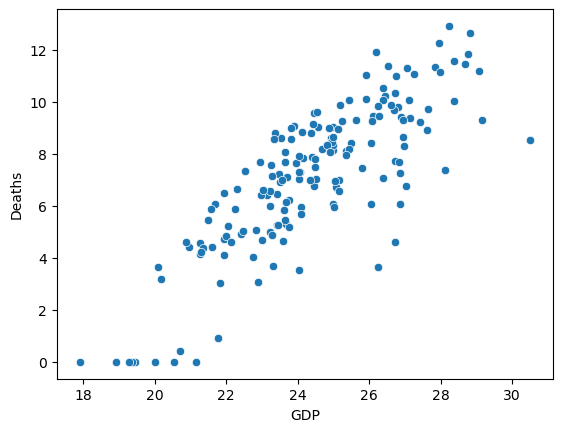

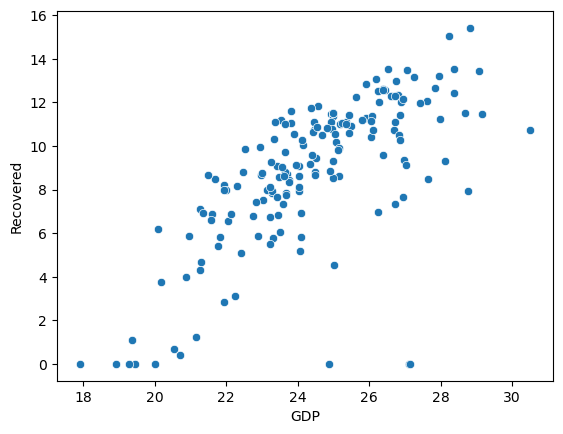

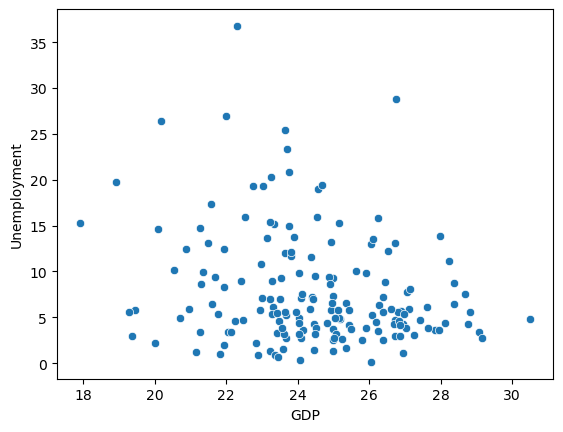

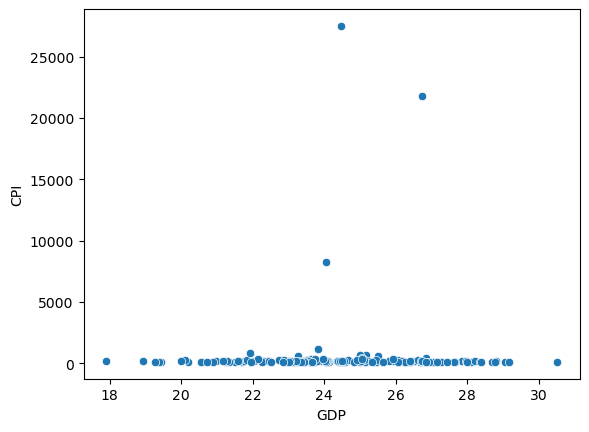

In [119]:
for col in df.columns:
    if col != "GDP":
        sns.scatterplot(data=df, x="GDP", y=col)
        plt.show()

<Axes: >

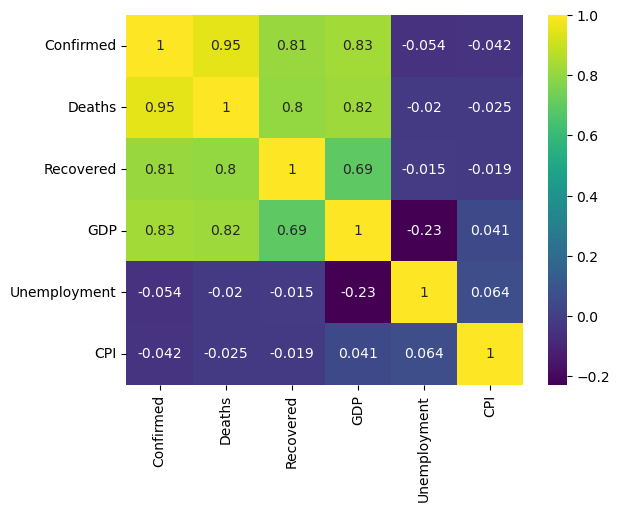

In [120]:
sns.heatmap(df.corr(),annot=True,cmap=plt.cm.viridis)

### Correlation Heatmap Insights

**Strong correlations between features and the label (GDP):**
- **Confirmed vs. GDP** — Moderate to strong positive correlation. Countries with larger economies tend to have larger populations and more widespread testing, leading to higher confirmed case counts.
- **Deaths vs. GDP** — Moderate to strong positive correlation, for the same population-related reasons as above.
- **Recovered vs. GDP** — Moderate positive correlation, following the same pattern.

**Strong correlations between features (multicollinearity):**
- **Confirmed vs. Deaths** — Very strong positive correlation. More confirmed cases naturally lead to more deaths, as deaths are a subset of confirmed cases.
- **Confirmed vs. Recovered** — Very strong positive correlation. Similarly, recoveries are a subset of confirmed cases.
- **Deaths vs. Recovered** — Strong positive correlation, as both scale proportionally with the total number of confirmed cases.

**Weak/no correlation:**
- **Unemployment** shows weak correlation with GDP and with the COVID-related features. Unemployment rates are influenced by many structural and policy factors beyond COVID impact alone.
- **CPI** shows weak correlation with all other features. CPI reflects domestic price levels and inflation, which vary widely across countries regardless of COVID case counts or economic size.

**Key takeaway:** The three COVID-related features (Confirmed, Deaths, Recovered) are the strongest predictors of GDP, but they are also highly correlated with each other. This multicollinearity is important to keep in mind — regularization techniques like **Ridge** and **Lasso** regression are specifically designed to handle this issue and may outperform vanilla linear regression on this dataset.

## Model Training

### Setup

- **Feature scaling:** StandardScaler (standardization)
- **Train/test split:** test_size=0.3, random_state=42
- **Evaluation metrics:** MAE, MSE, RMSE

### 1. Vanilla Linear Regression

Linear regression has no hyperparameters to tune. We use **K-fold cross-validation** (k=5) on the training set to assess model stability before evaluating on the test set.

In [121]:
from sklearn.linear_model import LinearRegression

In [122]:
def get_metrics(model, y_test, y_hat):
    mae = mean_absolute_error(y_test, y_hat)
    mse = mean_squared_error(y_test, y_hat)
    rmse = np.sqrt(mse)
    print(f"Model: {model.__class__.__name__}")
    print(f"MAE:{mae}\nMSE:{mse}\nRMSE:{rmse}")
    print(f"Beta Coefficients: {model.coef_}")
    return {"MAE": mae, "MSE": mse, "RMSE": rmse}

In [123]:
results = {}

In [124]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
scaler = StandardScaler()
scaled_x_train = scaler.fit_transform(X_train)
scaled_x_test = scaler.transform(X_test)


In [125]:
model = LinearRegression()
scores = cross_val_score(model,scaled_x_train,y_train,scoring='neg_mean_squared_error',cv=5)
print(scores)
print(abs(scores.mean()))

[-2.4611359  -0.83744747 -1.32443796 -1.0398746  -1.34529034]
1.4016372536181352


In [126]:
model.fit(scaled_x_train,y_train)
y_hat = model.predict(scaled_x_test)

In [127]:
metrics = get_metrics(model,y_test,y_hat)
results[model.__class__.__name__] = metrics


Model: LinearRegression
MAE:1.0832746667951558
MSE:1.9533641050908948
RMSE:1.3976280281573115
Beta Coefficients: [ 0.87171532  1.11719016 -0.08179581 -0.4839902  -0.0178495 ]


### 2. Ridge Regression

Ridge regression adds L2 regularization to handle multicollinearity. We use **RidgeCV** to find the optimal alpha (regularization strength) by testing values from 1 to 999.

In [128]:
from sklearn.linear_model import RidgeCV,Ridge

In [129]:
alphas = np.arange(1, 1000, 1)
ridge_cv = RidgeCV(alphas=alphas, scoring="neg_root_mean_squared_error")
ridge_cv.fit(scaled_x_train,y_train)
ridge_cv.alpha_

11.0

Conclusion: **11** is the optimal alpha

In [130]:
model = Ridge(alpha=11)
model.fit(scaled_x_train,y_train)
y_hat = model.predict(scaled_x_test)


In [131]:
metrics = get_metrics(model,y_test,y_hat)
results[model.__class__.__name__] = metrics

Model: Ridge
MAE:1.0454067697753842
MSE:1.8319696964667231
RMSE:1.3535027508160902
Beta Coefficients: [ 0.83635781  0.92563605  0.09142734 -0.4427822  -0.01424737]


### 3. Lasso Regression

Lasso regression adds L1 regularization, which can zero out coefficients entirely — performing **feature selection**. We use **LassoCV** to find the optimal alpha automatically.

In [132]:
from sklearn.linear_model import LassoCV,Lasso


In [133]:
model = LassoCV(eps=0.001, alphas=200,max_iter=10000)
model.fit(scaled_x_train,y_train)
y_hat = model.predict(scaled_x_test)
model.alpha_

np.float64(0.04121212806259055)

Conclusion: **73085594492.16005** is the optimal alpha

In [134]:
model = Lasso(alpha=0.04121212806259055)
model.fit(scaled_x_train,y_train)
y_hat = model.predict(scaled_x_test)

In [135]:
metrics = get_metrics(model,y_test,y_hat)
results[model.__class__.__name__] = metrics

Model: Lasso
MAE:1.0615306439159136
MSE:1.8694423548056402
RMSE:1.3672755226382283
Beta Coefficients: [ 0.82882903  1.05074705  0.         -0.44401768 -0.        ]


### 4. Polynomial Regression

Polynomial regression creates interaction and higher-order terms from the features. We test degrees 1 through 6, comparing train vs. test RMSE to identify the optimal degree before overfitting occurs.

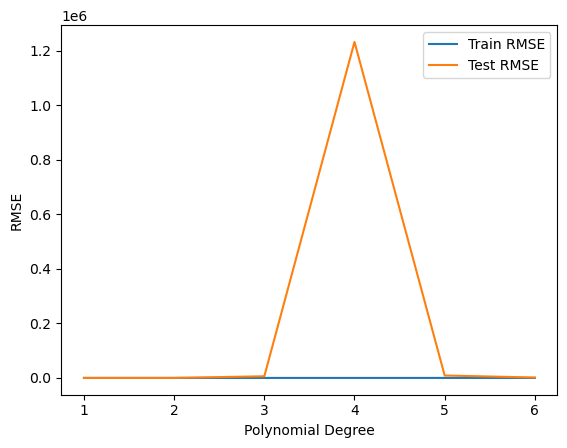

In [136]:
from sklearn.preprocessing import PolynomialFeatures
train_rmse_errors = []
test_rmse_errors = []

for degree in range(1, 7):
    polynomial_converter = PolynomialFeatures(degree=degree, include_bias=False)
    poly_x_train = polynomial_converter.fit_transform(scaled_x_train)
    poly_x_test = polynomial_converter.transform(scaled_x_test)

    model = LinearRegression()
    model.fit(poly_x_train, y_train)

    train_predictions = model.predict(poly_x_train)
    test_predictions = model.predict(poly_x_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

    train_rmse_errors.append(train_rmse)
    test_rmse_errors.append(test_rmse)

plt.plot(range(1, 7), train_rmse_errors, label="Train RMSE")
plt.plot(range(1, 7), test_rmse_errors, label="Test RMSE")
plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE")
plt.legend()
plt.show()


**Conclusion:** Degree **1** is the optimal polynomial degree. Higher degrees cause severe overfitting — with only ~118 training samples and 5 features, increasing the degree creates far more polynomial features than the data can support (e.g., degree 3 = 56 features, degree 4 = 126 features).

In [137]:
polynomial_converter = PolynomialFeatures(degree=1, include_bias=False)
poly_x_train = polynomial_converter.fit_transform(scaled_x_train)
poly_x_test = polynomial_converter.transform(scaled_x_test)
model = LinearRegression()
model.fit(poly_x_train, y_train)
y_hat = model.predict(poly_x_test)

In [138]:
metrics = get_metrics(model,y_test,y_hat)
results[model.__class__.__name__] = metrics


Model: LinearRegression
MAE:1.083274666795156
MSE:1.9533641050908963
RMSE:1.3976280281573121
Beta Coefficients: [ 0.87171532  1.11719016 -0.08179581 -0.4839902  -0.0178495 ]


## Multi Model Evaluation and Deployment

### Comparison of All Models' Metrics

In [139]:
plot_df = pd.DataFrame(results).T
plot_df

,MAE,MSE,RMSE
LinearRegression,1.083275,1.953364,1.397628
Ridge,1.045407,1.831970,1.353503
Lasso,1.061531,1.869442,1.367276


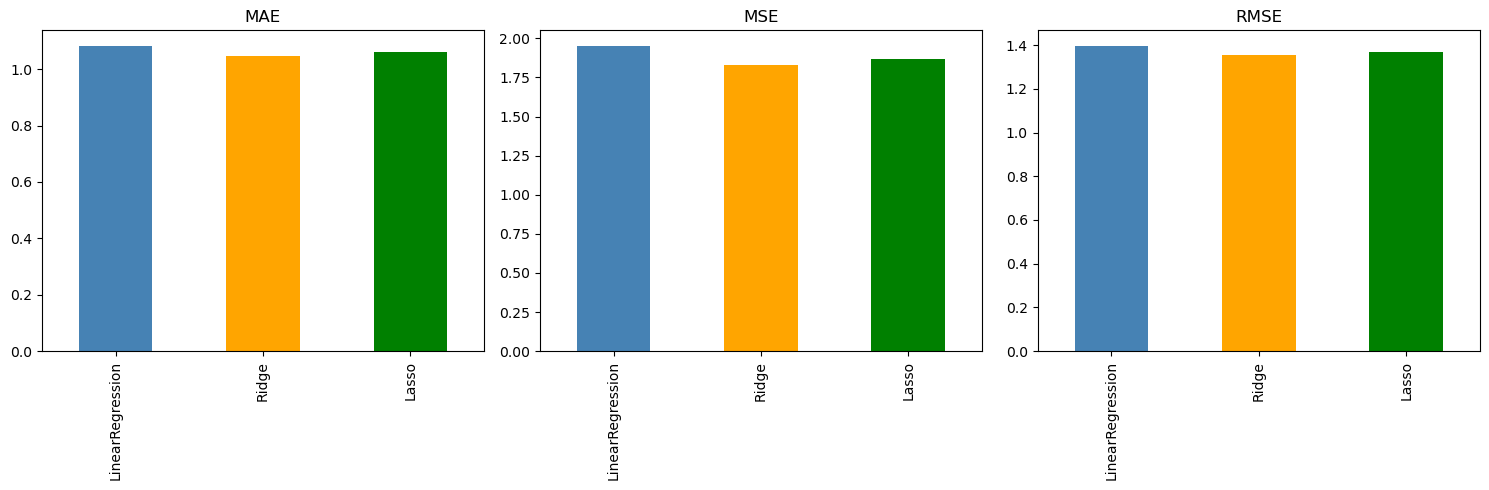

In [140]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_df["MAE"].plot(kind="bar", ax=axes[0], title="MAE", color=["steelblue", "orange", "green"])
plot_df["MSE"].plot(kind="bar", ax=axes[1], title="MSE", color=["steelblue", "orange", "green"])
plot_df["RMSE"].plot(kind="bar", ax=axes[2], title="RMSE", color=["steelblue", "orange", "green"])

plt.tight_layout()
plt.show()

### Best Model Selection

From the metrics and the plot, **Ridge Regression** is the most optimal model — it has the lowest MAE, MSE, and RMSE across all four trained models. This is the expected outcome given the multicollinearity we identified earlier between `Confirmed`, `Deaths`, and `Recovered`: the small L2 penalty (alpha = 11) shrinks the correlated coefficients just enough to stabilize the fit without losing meaningful signal, which plain Linear Regression and Lasso cannot do as cleanly.

### Train the Optimal Model on the Entire Dataset

We re-fit the scaler on the full dataset (X), then train the final Ridge model (with the alpha selected by RidgeCV) on all available data.

In [141]:
scaler = StandardScaler()
scaled_x_full = scaler.fit_transform(X)

final_model = Ridge(alpha=11)
final_model.fit(scaled_x_full, y)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",11
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


### Export to Joblib

Save the trained model, scaler, and polynomial converter to separate `.joblib` files for future use.

In [142]:
from joblib import dump, load
dump(final_model, "final_gdp_model.joblib")
dump(scaler, "scaler_gdp.joblib")

['scaler_gdp.joblib']

### Import from Joblib

Load the model and preprocessing instances back into fresh variables.

In [143]:
loaded_model = load('final_gdp_model.joblib')
loaded_scaler = load('scaler_gdp.joblib')

### Test the Loaded Model

Take a sample from X, preprocess it with the loaded scaler and polynomial converter, and generate a prediction to verify everything works.

In [144]:
sample = X.iloc[:1]
scaled_x = loaded_scaler.transform(sample)
predictions = loaded_model.predict(scaled_x)
print(f"Predicted: {predictions[0]:.2e}, Actual: {y.iloc[0]:.2e}")

Predicted: 2.45e+01, Actual: 2.36e+01
